# Parameter Estimation — Synthetic Polarization Curve

This notebook validates the `ParameterEstimation` pipeline by:

1. Building the Vetter & Schumacher (2019) PEMFC cell and running a steady-state
   polarization curve as the **forward model**.
2. Generating **synthetic experimental data** by evaluating the forward model at
   known "true" parameter values and adding Gaussian noise.
3. Estimating two parameters (`electrical_resistance` and `i0`, the ORR exchange
   current density) from the noisy data using `differential_evolution`.
4. Comparing recovered vs. true parameters and plotting the fit.

The same `model_fn` pattern can be reused for any cell model once it returns a
consistent output vector.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import marapendi as mrpd
from marapendi.simulation.estimation import ParameterEstimation, UnknownParameter


## 1 — Cell assembly (Vetter & Schumacher 2019 base case)

In [2]:
# ── Ionomer (Nafion NR-211) ──────────────────────────────────────────────
nafion = mrpd.PFSAIonomer(
    rho_dry_ion=1.97e3, EW_ion=1020,
    darken_num_ion=np.array([0., 67.74, -32.03, 3.842]),
    darken_den_ion=np.array([103.37, -33.013, -2.115, 1.0]),
    sorption_coeffs_ion=np.array([0.043, 17.81, -39.85, 36.0]),
    lmbd_liq_ref_ion=22, D_lmbd_ref_ion=1.0e-10, k_des_ref_ion=1.42e-4,
    E_act_ion=20e6, E_act_cond_ion=15e6, sigma_ref_ion=116.,
    f_v_perc_ion=0.06, n_sigma_ion=1.5,
    T_ref_sigma_ion=353.15, T_ref_D_ion=353.15, T_ref_des_ion=353.15,
)

# ── Current densities used for the polarization curve (A/m²) ─────────────
# Moderate range ensures steady-state convergence across the parameter space.
CURRENT_DENSITIES = np.linspace(200, 15000, 15)   # 0.02 to 1.5 A/cm²

# ── Operating conditions (Table 5) ───────────────────────────────────────
T_OP, P_OP, RH, S_C = 343.15, 1.5e5, 0.9, 0.12

# ── Fixed cell geometry (shared across all evaluations) ──────────────────
FIXED = dict(
    gdl_kw=dict(thickness=160e-6, eps_p=0.76, bulk_density=440.,
                bulk_specific_heat_capacity=710., bulk_thermal_conductivity=1.6,
                K_abs=6.15e-12, theta_contact=130., tort=1.6**2),
    memb_kw=dict(thickness=25e-6, bulk_thermal_conductivity=0.3, ionomer=nafion),
    ca_cl_kw=dict(thickness=10e-6, bulk_density=1000., bulk_specific_heat_capacity=710.,
                  bulk_thermal_conductivity=0.27, L_Pt=0.4e-2, wt_Pt=0.416,
                  ic_ratio=1.04, ecsa=75e3, tort=1.6**2, ionomer=nafion,
                  r_C=1e-10, K_abs=1e-13, theta_contact=95),
    an_cl_kw=dict(thickness=10e-6, bulk_density=1000., bulk_specific_heat_capacity=710.,
                  bulk_thermal_conductivity=0.27, L_Pt=0.4e-2/3, wt_Pt=0.192,
                  ic_ratio=1.07, ecsa=75e3, tort=1.6**2, ionomer=nafion,
                  r_C=1e-10, K_abs=1e-13, theta_contact=95),
)
print("Fixed geometry ready.")


Fixed geometry ready.


## 2 — Forward model

`model_fn(params)` rebuilds the cell with updated parameters, runs a warm-started
steady-state sweep over `CURRENT_DENSITIES`, and returns the voltage vector.
Returns `NaN` for steps that fail to converge (handled by `ParameterEstimation`).


In [3]:
def model_fn(params: dict) -> np.ndarray:
    """Forward model: returns V_cell at CURRENT_DENSITIES for the given params."""
    orr = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params['i0'],
        activation_energy=67e6, reaction_order=0.54,
        reference_activity=1.e5, reference_temperature=353.15,
        number_of_electrons=1, charge_transfer_coeff=1,
    )
    ca_cl_kw = {**FIXED['ca_cl_kw'], 'reaction': orr}
    cell = mrpd.Cell(
        area=25e-4,
        electrical_resistance=params['electrical_resistance'],
        thermal_resistance=0,
        ca=mrpd.CellSide(
            cl=mrpd.PtCCatalystLayer(**ca_cl_kw),
            gdl=mrpd.PorousLayer(**FIXED['gdl_kw']),
            ch=mrpd.FlowChannel(height=1e-3, bulk_thermal_conductivity=100.),
            has_mpl=False,
        ),
        an=mrpd.CellSide(
            cl=mrpd.PtCCatalystLayer(**FIXED['an_cl_kw']),
            gdl=mrpd.PorousLayer(**FIXED['gdl_kw']),
            ch=mrpd.FlowChannel(height=1e-3, bulk_thermal_conductivity=100.),
            has_mpl=False,
        ),
        memb=mrpd.PFSAMembrane(**FIXED['memb_kw']),
    )
    base  = mrpd.CellBaseModel(
        transient_transport_model=mrpd.TransientCellModel(cell=cell, current_density=0.),
        memb_model=mrpd.PFSAModel(),
        cl_model=mrpd.PtCCatalystLayerModel(),
        gas_diffusion_model=mrpd.PorousGasResistanceModel(),
        darcy_transport_model=mrpd.DarcyTransportModel(),
        voltage_model=mrpd.VoltageModel(),
    )
    model = base.transient_transport_model

    y0 = base.initial_state(
        cell_temperature=T_OP, cell_pressure=P_OP,
        ca_rh=RH, an_rh=RH, ca_dry_o2=0.21, an_dry_h2=1.0, s_ca=S_C,
    )

    V_arr = np.full(len(CURRENT_DENSITIES), np.nan)
    y = y0.copy()
    for k, i_k in enumerate(CURRENT_DENSITIES):
        model.current_density = float(i_k)
        sol = base.solve_steady_state(y, t=0.)
        if not sol.success:
            break
        st  = base.postprocess(sol.y, i_density=float(i_k))
        V_k = float(st.V_cell[0])
        if V_k <= 0.:
            break
        V_arr[k] = V_k
        y = sol.y[:, 0]

    return V_arr


## 3 — Nominal parameters and synthetic data

True curve:  15/15 points converged
V range: [0.512, 0.903] V


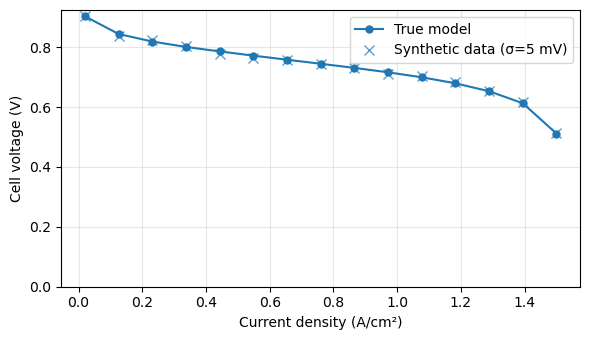

In [4]:
# ── True (reference) parameters ──────────────────────────────────────────
TRUE_PARAMS = {
    'electrical_resistance': 30e-7,   # Ω·m²  (Vetter value: 80μm/1250 + 5μm/350)
    'i0':                    2.45e-4,   # A/m²_Pt
}

# ── Generate "true" polarization curve ───────────────────────────────────
V_true = model_fn(TRUE_PARAMS)
i_Acm2 = CURRENT_DENSITIES / 1e4

# ── Add Gaussian noise (σ = 5 mV) to simulate measurement error ──────────
rng       = np.random.default_rng(seed=42)
NOISE_STD = 5e-3   # V
V_exp     = V_true + rng.normal(0, NOISE_STD, size=V_true.shape)
V_exp[np.isnan(V_true)] = np.nan   # keep failed steps as NaN

print(f"True curve:  {np.sum(~np.isnan(V_true))}/{len(CURRENT_DENSITIES)} points converged")
print(f"V range: [{np.nanmin(V_true):.3f}, {np.nanmax(V_true):.3f}] V")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(i_Acm2, V_true, 'C0-o', ms=5, label='True model')
ax.plot(i_Acm2, V_exp,  'C0x',  ms=7, alpha=0.7, label=f'Synthetic data (σ={NOISE_STD*1000:.0f} mV)')
ax.set_xlabel('Current density (A/cm²)')
ax.set_ylabel('Cell voltage (V)')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## 4 — Define the estimation problem

Set up `ParameterEstimation` with deliberately wrong nominal parameter values to
confirm that the estimator can recover the true values from the noisy data.


In [5]:
# ── Deliberately perturbed nominal values (starting point) ───────────────
NOMINAL_PARAMS = {
    'electrical_resistance': 5e-7,   # wrong by ~2×
    'i0':                    1e-4,   # wrong by ~2.5×
}

unknown_params = [
    UnknownParameter(
        key='electrical_resistance',
        label=r'$r_{elec}$',
        units='Ω·m²',
        lower=20e-7,
        upper=60e-7,
        log_scale=False,
    ),
    UnknownParameter(
        key='i0',
        label=r'$i_{0,ca}$',
        units='A/m²_Pt',
        lower=1e-5,
        upper=1e-2,
        log_scale=True,
    ),
]

est = ParameterEstimation(
    model_fn=model_fn,
    params=NOMINAL_PARAMS,
    unknown_parameters=unknown_params,
)

# Verify that the model evaluates at nominal values
V_nominal = est.evaluate()
print("Nominal model evaluated OK, V range:",
      f"[{np.nanmin(V_nominal):.3f}, {np.nanmax(V_nominal):.3f}] V")


Nominal model evaluated OK, V range: [0.523, 0.877] V


## 5 — Local sensitivity analysis

Before estimating, confirm that both parameters have non-zero sensitivity across
the polarization curve — a necessary condition for identifiability.


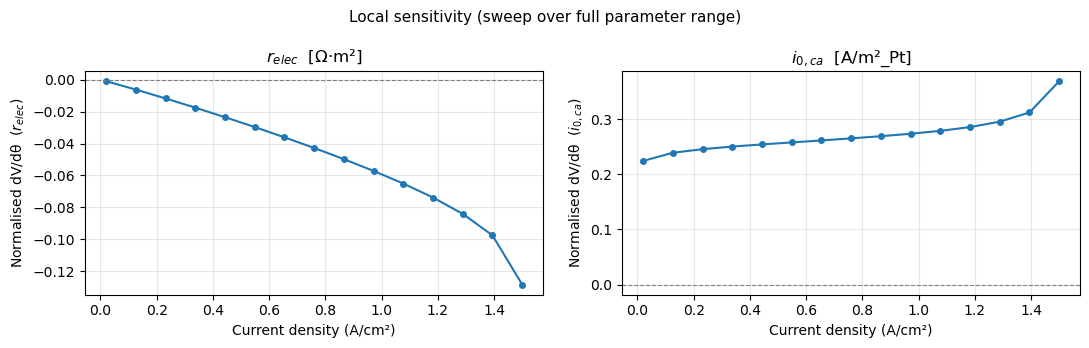


Mean |S| per parameter:
  $r_{elec}$     : 0.0483
  $i_{0,ca}$     : 0.2721


In [6]:
S = est.calculate_local_sensitivity(n_samples=5)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=False)
fig.suptitle("Local sensitivity (sweep over full parameter range)", fontsize=11)

for j, up in enumerate(unknown_params):
    ax = axes[j]
    ax.plot(i_Acm2, S[j], 'C0-o', ms=4)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlabel('Current density (A/cm²)')
    ax.set_ylabel(f'Normalised dV/dθ  ({up.label})')
    ax.set_title(f'{up.label}  [{up.units}]')
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print("\nMean |S| per parameter:")
for j, up in enumerate(unknown_params):
    print(f"  {up.label:15s}: {np.nanmean(np.abs(S[j])):.4f}")


## 6 — Parameter estimation

### Strategy comparison

| Method | Evaluations | Notes |
|---|---|---|
| `differential_evolution` | ~5000 | Robust global search, slow |
| `L-BFGS-B` × 1 start | ~100 | Fast if starting near solution |
| **`L-BFGS-B` × 10 starts** | **~1000** | **10–20× faster than DE, recommended** |
| Bayesian opt (optuna) | ~50–100 | Best for very expensive models |

`n_restarts` draws starting points from a Sobol sequence so the normalised
parameter space is covered without random clustering.  The first restart uses the
nominal values (or `initial_guess`); subsequent ones explore the rest of the space.


In [ ]:
import time

# ── Multi-start L-BFGS-B ─────────────────────────────────────────────────
N_RESTARTS = 10

t0 = time.perf_counter()
sol, p_hat = est.estimate(
    V_exp,
    method='L-BFGS-B',
    n_restarts=N_RESTARTS,
    penalty_threshold=0.,     # L-BFGS-B is accurate enough without penalty
    ftol=1e-12,
    maxiter=200,
    print_iterations=True,
)
t_elapsed = time.perf_counter() - t0

print(f"\nDone in {t_elapsed:.1f} s  ({sol.nfev} total model evaluations, "
      f"best obj = {sol.fun:.4g})")
print()
print(f"{'Parameter':<26} {'True':>12} {'Nominal':>12} {'Estimated':>12} {'Error (%)':>10}")
print('-' * 63)
for up in unknown_params:
    true  = TRUE_PARAMS[up.key]
    nom   = NOMINAL_PARAMS[up.key]
    est_v = p_hat[up.key]
    err   = 100 * (est_v - true) / true
    print(f"{up.label:<26} {true:>12.4g} {nom:>12.4g} {est_v:>12.4g} {err:>+9.1f}%")


## 7 — Results

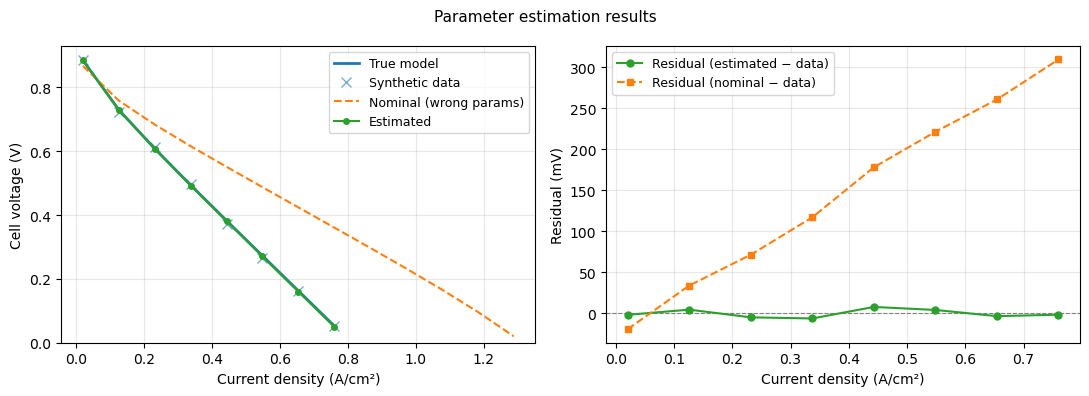

RMSE nominal:   181.95 mV
RMSE estimated: 4.72 mV


In [ ]:
V_hat = model_fn(p_hat)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Parameter estimation results", fontsize=11)

# ── Left: polarization curves ─────────────────────────────────────────────
ax1.plot(i_Acm2, V_true,    'C0-',  lw=2,   label='True model')
ax1.plot(i_Acm2, V_exp,     'C0x',  ms=7, alpha=0.6, label='Synthetic data')
ax1.plot(i_Acm2, V_nominal, 'C1--', lw=1.5, label='Nominal (wrong params)')
ax1.plot(i_Acm2, V_hat,     'C2-o', ms=4,   label='Estimated')
ax1.set_xlabel('Current density (A/cm²)')
ax1.set_ylabel('Cell voltage (V)')
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# ── Right: residuals ──────────────────────────────────────────────────────
valid = np.isfinite(V_exp) & np.isfinite(V_hat)
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.plot(i_Acm2[valid], (V_hat[valid] - V_exp[valid]) * 1e3, 'C2-o', ms=5,
         label='Residual (estimated − data)')
ax2.plot(i_Acm2[valid], (V_nominal[valid] - V_exp[valid]) * 1e3, 'C1--s', ms=4,
         label='Residual (nominal − data)')
ax2.set_xlabel('Current density (A/cm²)')
ax2.set_ylabel('Residual (mV)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

rmse_nom = np.sqrt(np.nanmean((V_nominal[valid] - V_exp[valid])**2)) * 1e3
rmse_est = np.sqrt(np.nanmean((V_hat[valid]     - V_exp[valid])**2)) * 1e3
print(f"RMSE nominal:   {rmse_nom:.2f} mV")
print(f"RMSE estimated: {rmse_est:.2f} mV")
